# CardioIA — Ir Além 2: Diagnóstico visual de ECG com rede neural (MLP)

**Tarefa:** classificar batimentos de ECG como **normal** ou **anormal** usando um Perceptron Multicamadas (MLP) em Keras.

**Dataset:** [Heartbeat (Kaggle, Shayan Fazeli)](https://www.kaggle.com/datasets/shayanfazeli/heartbeat), subconjunto **PTB Diagnostic ECG Database**
(`ptbdb_normal.csv` e `ptbdb_abnormal.csv`): 14.552 batimentos, cada um com 187 amostras (125 Hz) já normalizadas entre 0 e 1, rótulo binário.

**Pontos de atenção do enunciado:** o dataset recomendado entrega o ECG como *sinal* (vetor de 187 números), não como arquivo de imagem.
Para cumprir o pré-processamento de imagem (redimensionar + tons de cinza), cada batimento é **renderizado como uma imagem 64×64 em tons de cinza**
e o MLP é treinado nessas imagens (modelo principal). Como comparação, treinamos também um MLP no sinal bruto.

> ⚠️ Projeto educacional. Não é um dispositivo médico.

In [1]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
keras.utils.set_random_seed(SEED)
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.16.0.dev2026100704 | backend: tensorflow


## 1. Carregando os dados

In [2]:
normal = pd.read_csv(RAIZ / "data" / "ptbdb_normal.csv", header=None)
anormal = pd.read_csv(RAIZ / "data" / "ptbdb_abnormal.csv", header=None)
dados = pd.concat([normal, anormal], ignore_index=True)
X_sinal = dados.iloc[:, :187].to_numpy(dtype="float32")
y = dados.iloc[:, 187].to_numpy(dtype="int")      # 0 = normal, 1 = anormal
print("sinais:", X_sinal.shape, "| NaN:", int(np.isnan(X_sinal).sum()), "| min/max:", X_sinal.min(), X_sinal.max())
print("normal:", (y == 0).sum(), f"({(y == 0).mean():.1%})", "| anormal:", (y == 1).sum(), f"({(y == 1).mean():.1%})")

sinais: (14552, 187) | NaN: 0 | min/max: 0.0 1.0
normal: 4046 (27.8%) | anormal: 10506 (72.2%)


**Desbalanceamento:** ~72% dos batimentos são anormais. Um "modelo" que responde sempre *anormal* já tem ~72% de acurácia,
então essa é a **linha de base** que o MLP precisa superar de forma clara.

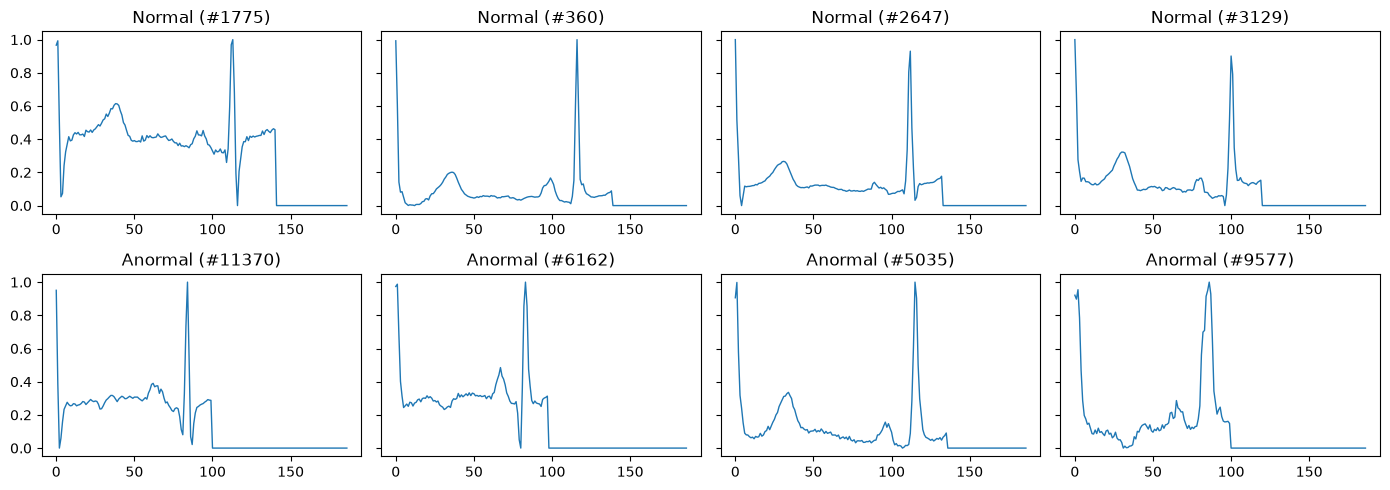

In [3]:
fig, axs = plt.subplots(2, 4, figsize=(14, 5), sharey=True)
rng = np.random.default_rng(SEED)
for lin, (cls, nome) in enumerate([(0, "Normal"), (1, "Anormal")]):
    for ax, i in zip(axs[lin], rng.choice(np.where(y == cls)[0], 4, replace=False)):
        ax.plot(X_sinal[i], lw=1); ax.set_title(f"{nome} (#{i})")
plt.tight_layout(); plt.show()

## 2. Pré-processamento das imagens

Cada batimento (187 pontos, valores 0–1) é convertido em uma imagem **64×64 em tons de cinza**:
- eixo X reamostrado para 64 colunas (redimensionamento);
- eixo Y quantizado em 64 linhas; traço preto (0) sobre fundo branco (1), com os saltos verticais preenchidos para a curva ficar contínua;
- valores finais em [0, 1] e *flatten* para 4096 entradas do MLP.

In [4]:
TAM = 64

def sinal_para_imagem(sinal, tam=TAM):
    x = np.interp(np.linspace(0, len(sinal) - 1, tam), np.arange(len(sinal)), sinal)
    linhas = np.clip(np.round((1 - x) * (tam - 1)).astype(int), 0, tam - 1)   # topo = valor máximo
    img = np.ones((tam, tam), dtype="float32")
    for c in range(tam):
        prox = linhas[min(c + 1, tam - 1)]
        a, b = sorted((linhas[c], prox))
        img[a:b + 1, c] = 0.0
    return img

X_img = np.stack([sinal_para_imagem(s) for s in X_sinal])
print("imagens:", X_img.shape, X_img.dtype, "| min/max:", X_img.min(), X_img.max())

imagens: (14552, 64, 64) float32 | min/max: 0.0 1.0


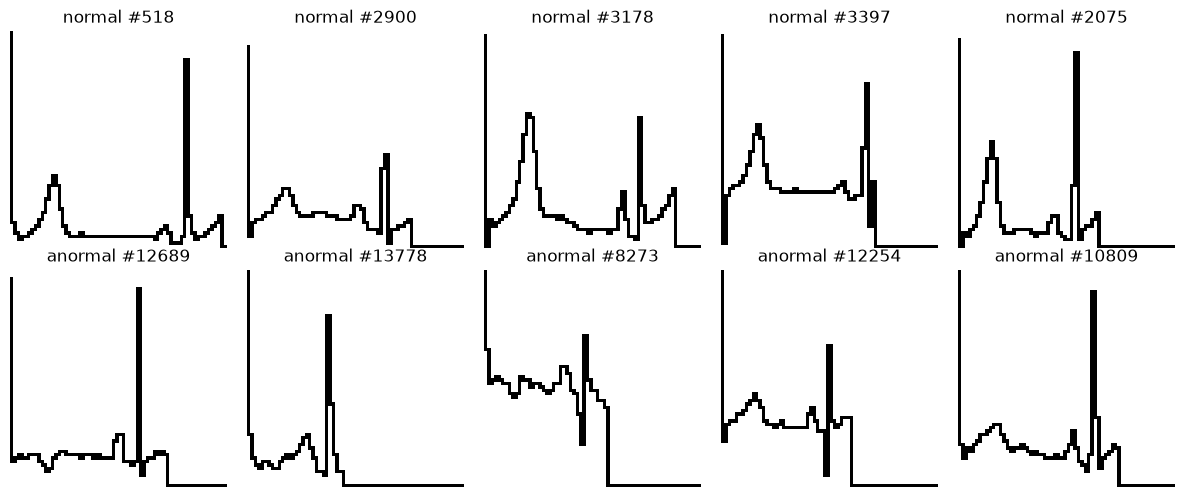

In [5]:
(RAIZ / "images").mkdir(exist_ok=True)
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for lin, (cls, nome) in enumerate([(0, "normal"), (1, "anormal")]):
    for k, (ax, i) in enumerate(zip(axs[lin], rng.choice(np.where(y == cls)[0], 5, replace=False))):
        ax.imshow(X_img[i], cmap="gray", vmin=0, vmax=1); ax.set_title(f"{nome} #{i}"); ax.axis("off")
        plt.imsave(RAIZ / "images" / f"exemplo_{nome}_{k + 1}.png", X_img[i], cmap="gray", vmin=0, vmax=1)
plt.tight_layout(); plt.show()

## 3. Divisão treino / validação / teste

70% / 15% / 15%, estratificada pelo rótulo. O conjunto de **teste só é usado no final**; a validação serve para o *early stopping*.

In [6]:
idx = np.arange(len(y))
i_tr, i_tmp = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
i_va, i_te = train_test_split(i_tmp, test_size=0.50, stratify=y[i_tmp], random_state=SEED)
print(len(i_tr), "treino |", len(i_va), "validação |", len(i_te), "teste")
print("proporção de anormais (tr/va/te):", [round(y[i].mean(), 3) for i in (i_tr, i_va, i_te)])
base = max((y[i_te] == 0).mean(), (y[i_te] == 1).mean())
print(f"Linha de base (sempre 'anormal') no teste: {base:.3f}")

10186 treino | 2183 validação | 2183 teste
proporção de anormais (tr/va/te): [np.float64(0.722), np.float64(0.722), np.float64(0.722)]
Linha de base (sempre 'anormal') no teste: 0.722


## 4. Rede MLP em Keras

Arquitetura: `Entrada → Dense(256, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.3) → Dense(1, sigmoid)`.
Perda: entropia cruzada binária; otimizador Adam; **pesos de classe** para compensar o desbalanceamento; *early stopping* na perda de validação.

In [7]:
def construir_mlp(n_entrada):
    m = keras.Sequential([
        layers.Input(shape=(n_entrada,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

def treinar(X, nome):
    keras.utils.set_random_seed(SEED)
    Xf = X.reshape(len(X), -1)
    pesos = compute_class_weight("balanced", classes=np.array([0, 1]), y=y[i_tr])
    modelo = construir_mlp(Xf.shape[1])
    hist = modelo.fit(Xf[i_tr], y[i_tr], validation_data=(Xf[i_va], y[i_va]),
                      epochs=60, batch_size=64, class_weight={0: pesos[0], 1: pesos[1]}, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
    print(f"[{nome}] épocas treinadas: {len(hist.history['loss'])}")
    return modelo, hist, Xf

modelo_img, hist_img, Xf_img = treinar(X_img, "MLP em imagens 64x64")
modelo_img.summary()

[MLP em imagens 64x64] épocas treinadas: 47


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,196,037 (12.19 MB)

 Trainable params: 1,065,345 (4.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,130,692 (8.13 MB)

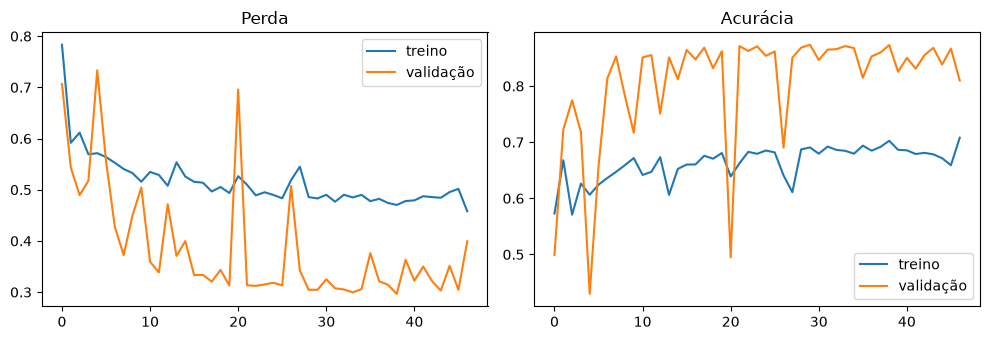

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(hist_img.history["loss"], label="treino"); axs[0].plot(hist_img.history["val_loss"], label="validação"); axs[0].set_title("Perda"); axs[0].legend()
axs[1].plot(hist_img.history["accuracy"], label="treino"); axs[1].plot(hist_img.history["val_accuracy"], label="validação"); axs[1].set_title("Acurácia"); axs[1].legend()
plt.tight_layout(); (RAIZ / "assets").mkdir(exist_ok=True); plt.savefig(RAIZ / "assets" / "curvas_treino.png", dpi=130); plt.show()

## 5. Avaliação no conjunto de teste

=== MLP em imagens 64x64 ===
Acurácia: 0.8621 | AUC-ROC: 0.9249
              precision    recall  f1-score   support

      normal      0.768     0.722     0.744       607
     anormal      0.895     0.916     0.906      1576

    accuracy                          0.862      2183
   macro avg      0.832     0.819     0.825      2183
weighted avg      0.860     0.862     0.861      2183



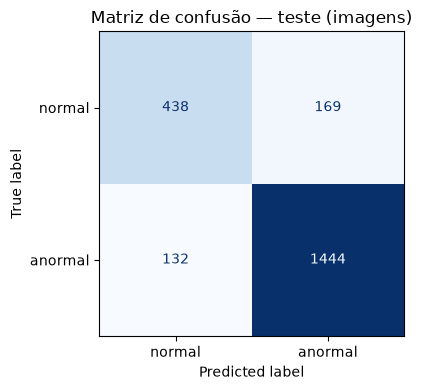

In [9]:
def avaliar(modelo, Xf, nome):
    p = modelo.predict(Xf[i_te], verbose=0).ravel()
    pred = (p >= 0.5).astype(int)
    print(f"=== {nome} ===")
    print(f"Acurácia: {accuracy_score(y[i_te], pred):.4f} | AUC-ROC: {roc_auc_score(y[i_te], p):.4f}")
    print(classification_report(y[i_te], pred, target_names=["normal", "anormal"], digits=3))
    return pred

pred_img = avaliar(modelo_img, Xf_img, "MLP em imagens 64x64")
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y[i_te], pred_img, display_labels=["normal", "anormal"], ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão — teste (imagens)"); plt.tight_layout()
plt.savefig(RAIZ / "assets" / "matriz_confusao_mlp.png", dpi=130); plt.show()

**Como ler:** em triagem cardiológica, o erro perigoso é o **falso negativo** (batimento anormal classificado como normal).
Veja o *recall* da classe "anormal" e a célula inferior esquerda da matriz.

## 6. Comparação: MLP no sinal bruto (187 amostras)

In [10]:
modelo_sin, hist_sin, Xf_sin = treinar(X_sinal, "MLP no sinal 1D")
pred_sin = avaliar(modelo_sin, Xf_sin, "MLP no sinal 1D")

[MLP no sinal 1D] épocas treinadas: 42
=== MLP no sinal 1D ===
Acurácia: 0.9478 | AUC-ROC: 0.9881
              precision    recall  f1-score   support

      normal      0.871     0.954     0.910       607
     anormal      0.982     0.945     0.963      1576

    accuracy                          0.948      2183
   macro avg      0.926     0.950     0.937      2183
weighted avg      0.951     0.948     0.948      2183



## 7. Exemplos de erros (falsos negativos)

falsos negativos (imagens): 132 de 1576 anormais no teste


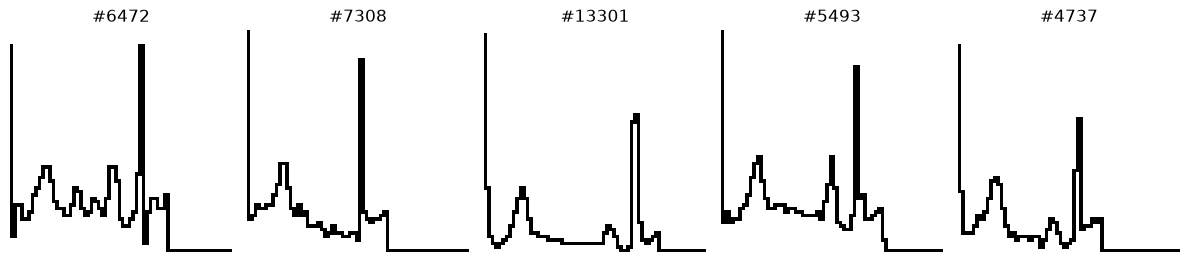

In [11]:
fn = i_te[(y[i_te] == 1) & (pred_img == 0)]
print("falsos negativos (imagens):", len(fn), "de", int((y[i_te] == 1).sum()), "anormais no teste")
fig, axs = plt.subplots(1, 5, figsize=(12, 2.8))
for ax, i in zip(axs, fn[:5]):
    ax.imshow(X_img[i], cmap="gray"); ax.axis("off"); ax.set_title(f"#{i}")
plt.tight_layout(); plt.show()

## 8. Conclusões e limitações

Os resultados numéricos aparecem nas saídas acima e estão resumidos no README. Cuidados ao interpretá-los:

- **Vazamento por paciente:** o PTB-DB tem *vários batimentos do mesmo paciente*, e o CSV não traz o identificador do paciente.
  Com divisão aleatória por batimento, batimentos do mesmo paciente caem em treino e teste, o que **infla a acurácia**.
  Uma avaliação honesta exigiria dividir **por paciente**.
- **Desbalanceamento:** ~72% anormais; por isso comparamos com a linha de base e olhamos recall/AUC, não só acurácia.
- **"Anormal" é um rótulo amplo:** agrupa diferentes cardiopatias (principalmente infarto do miocárdio); o modelo não diagnostica doença específica.
- **Conversão sinal→imagem:** a imagem 64×64 perde resolução do sinal original; o MLP em imagens não é, em princípio, melhor que no sinal — é uma exigência didática do enunciado.
- **MLP ignora a ordem espacial** dos pixels; CNNs/1D-CNNs costumam render mais nesse tipo de dado.
- Uso real exigiria validação clínica, dados de múltiplas instituições e supervisão médica.